# DKD + Dual MLP-Learnable Temperatures (CTKD-style) — PlantVillage

---

### Method Summary

This notebook extends **Decoupled Knowledge Distillation** (Zhao et al., CVPR 2022) with
**dual MLP-driven learnable temperatures** inspired by CTKD (Li et al., ECCV 2022).
Instead of a single scalar per temperature, each temperature is produced by a small
two-layer MLP that takes the batch-mean student logits as input.
This allows each temperature to follow a richer, non-monotone trajectory conditioned on
the student's current prediction confidence and class distribution.

Two independent MLP heads — one for TCKD, one for NCKD — each output a scalar $\phi$
that is sigmoid-constrained to $[\tau_{min}, \tau_{max}]$:

$$\tau_{TCKD} = \tau_{min} + (\tau_{max} - \tau_{min}) \cdot \sigma\bigl(\mathrm{MLP}_{TCKD}(\bar{z}^S)\bigr)$$

$$\tau_{NCKD} = \tau_{min} + (\tau_{max} - \tau_{min}) \cdot \sigma\bigl(\mathrm{MLP}_{NCKD}(\bar{z}^S)\bigr)$$

A Gradient Reversal Layer (GRL) is applied to the MLP output before sigmoid, so both
temperatures are pushed adversarially to maximise the loss while the student minimises it.

$$\mathcal{L}_{TCKD} = \text{BCE}\bigl(\sigma(z^T / \tau_{TCKD}),\; \sigma(z^S / \tau_{TCKD})\bigr)$$

$$\mathcal{L}_{NCKD} = \text{KL}\bigl(\hat{p}^T(\tau_{NCKD}) \| \hat{p}^S(\tau_{NCKD})\bigr)$$

$$\mathcal{L} = \mathcal{L}_{CE}^{\text{smooth}} + \alpha \cdot \mathcal{L}_{TCKD} + \beta \cdot \mathcal{L}_{NCKD}$$

---
**Teacher:** ResNet-18 loaded from `checkpoints/pv_resnet18_teacher.pth`  
**Student:** MobileNetV2 trained from scratch (no pretrained weights)  
**Training regime:** SGD + Nesterov, CosineAnnealingLR T_max=125 eta_min=1e-4, lr=0.05, wd=1e-4  
**Checkpoint:** `checkpoints/pv_b7_mobilenetv2_dkd_dual_mlp_temp.pth`


## 1. Environment Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import torchvision.transforms as transforms
import torchvision.models as models

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

from PIL import Image
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')
import kagglehub

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
print(f'PyTorch : {torch.__version__}')


Device  : cuda
GPU     : NVIDIA GeForce RTX 3050 6GB Laptop GPU
PyTorch : 2.5.1


## 2. Configuration

Changes from v5: changing LR_TEMP from 1e-3 to 1e-4 

Changes from v4: changed LR from 0.05 to 0.075

In [ ]:
print('Fetching dataset via kagglehub...')
base_path = Path(kagglehub.dataset_download('abdallahalidev/plantvillage-dataset'))
PV_ROOT   = base_path / 'color'

CKPT_DIR = Path('./checkpoints')
CKPT_DIR.mkdir(parents=True, exist_ok=True)

TEACHER_CKPT = CKPT_DIR / 'pv_resnet18_teacher.pth'

# -- Image & model ------------------------------------------------------------
IMG_SIZE    = 64
NUM_CLASSES = 38

# ImageNet normalisation (same as teacher and baselines notebooks)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# -- Training schedule (matches retrained baseline notebooks) -----------------
EPOCHS     = 60
BATCH_SIZE = 64
LR         = 0.075
MOMENTUM   = 0.9
WEIGHT_DECAY = 1e-4

# -- DKD loss weights ---------------------------------------------------------
ALPHA = 0.5   # weight on TCKD loss
BETA  = 10.0   # weight on NCKD loss

# -- Temperature constraints --------------------------------------------------
TAU_MIN = 2.0    # sigmoid lower bound
TAU_MAX = 10.0   # sigmoid upper bound

# -- Temperature MLP architecture ---------------------------------------------
# Each temperature MLP: Linear(NUM_CLASSES, H) -> ReLU -> Linear(H, H) -> ReLU -> Linear(H, 1)
# Input is the mean-pooled student logits (shape [C]) — rich signal about current predictions
MLP_HIDDEN_DIM = 64   # hidden units per temperature MLP

# -- Temperature learning rate (separate param group) -------------------------
LR_TEMP = 1e-4

# -- GRL lambda schedule ------------------------------------------------------
GRL_LAMBDA_MAX = 1.0

print('Configuration loaded.')
print(f'  Epochs         : {EPOCHS}')
print(f'  Batch size     : {BATCH_SIZE}')
print(f'  LR             : {LR}')
print(f'  Weight decay   : {WEIGHT_DECAY}')
print(f'  Scheduler      : CosineAnnealingLR T_max={EPOCHS} eta_min=1e-4')
print(f'  alpha / beta   : {ALPHA} / {BETA}')
print(f'  tau range      : [{TAU_MIN}, {TAU_MAX}]')
print(f'  MLP hidden dim : {MLP_HIDDEN_DIM}  (per temperature head)')
print(f'  LR_TEMP        : {LR_TEMP}')
print(f'  GRL lambda max : {GRL_LAMBDA_MAX}')
print(f'  CE loss        : label_smoothing=0.1')
print(f'  Pretrained     : None (training from scratch)')


Fetching dataset via kagglehub...
Configuration loaded.
  Epochs         : 60
  Batch size     : 64
  LR             : 0.075
  Weight decay   : 0.0001
  Scheduler      : CosineAnnealingLR T_max=60 eta_min=1e-4
  alpha / beta   : 0.5 / 10.0
  tau range      : [2.0, 10.0]
  MLP hidden dim : 64  (per temperature head)
  LR_TEMP        : 0.0001
  GRL lambda max : 1.0
  CE loss        : label_smoothing=0.1
  Pretrained     : None (training from scratch)


## 3. PlantVillage Dataset — Stratified 80/10/10 Split

Identical dataset class, split logic, and transforms to the teacher and baselines notebooks
(SEED=42, same class ordering).


In [3]:
class PlantVillageDataset(Dataset):
    """Custom Dataset backed by pre-split path arrays."""
    def __init__(self, paths, labels, class_to_idx, transform=None):
        self.paths        = paths
        self.labels       = labels
        self.class_to_idx = class_to_idx
        self.transform    = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.class_to_idx[self.labels[idx]]


In [4]:
# -- Collect paths and labels (identical to all other PV notebooks) -----------
class_dirs   = sorted([d for d in PV_ROOT.iterdir() if d.is_dir()])
class_names  = [d.name for d in class_dirs]
class_to_idx = {n: i for i, n in enumerate(class_names)}

all_paths, all_labels = [], []
for d in class_dirs:
    imgs = (list(d.glob('*.JPG')) + list(d.glob('*.jpg')) +
            list(d.glob('*.PNG')) + list(d.glob('*.png')))
    all_paths.extend(imgs)
    all_labels.extend([d.name] * len(imgs))

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)

# -- Stratified 80/10/10 split ------------------------------------------------
train_idx, temp_idx = train_test_split(
    np.arange(len(all_labels)), test_size=0.20,
    stratify=all_labels, random_state=SEED
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50,
    stratify=all_labels[temp_idx], random_state=SEED
)

# -- Transforms ---------------------------------------------------------------
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.25),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# -- Datasets and loaders -----------------------------------------------------
train_ds = PlantVillageDataset(all_paths[train_idx], all_labels[train_idx], class_to_idx, train_tf)
val_ds   = PlantVillageDataset(all_paths[val_idx],   all_labels[val_idx],   class_to_idx, eval_tf)
test_ds  = PlantVillageDataset(all_paths[test_idx],  all_labels[test_idx],  class_to_idx, eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE * 2,        shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE * 2,        shuffle=False, num_workers=2, pin_memory=True)

print(f'PlantVillage — {NUM_CLASSES} classes')
print(f'  Train : {len(train_ds):,}  ({len(train_loader)} batches)')
print(f'  Val   : {len(val_ds):,}  ({len(val_loader)} batches)')
print(f'  Test  : {len(test_ds):,}  ({len(test_loader)} batches)')
print(f'  Image : {IMG_SIZE}x{IMG_SIZE}')


PlantVillage — 38 classes
  Train : 43,443  (679 batches)
  Val   : 5,430  (43 batches)
  Test  : 5,431  (43 batches)
  Image : 64x64


## 4. Model Definitions

### 4.1 Teacher — ResNet-18

Teacher-loading logic identical to `pv_dkd.ipynb`: auto-detects conv1 kernel size,
handles both standard (7×7) and CIFAR-adapted (3×3) checkpoints, and strips DataParallel prefixes.


In [5]:
def build_resnet18_pv(num_classes):
    """Standard ResNet-18 for 128x128 PlantVillage (no conv1/maxpool changes needed)."""
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(512, num_classes)
    return m


def build_resnet18_cifar(num_classes):
    """CIFAR-adapted ResNet-18 (3x3 conv1, no maxpool) — fallback detection."""
    m = models.resnet18(weights=None)
    m.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    m.fc      = nn.Linear(512, num_classes)
    return m


def load_teacher(ckpt_path, num_classes, device):
    """
    Robust teacher loader — identical to pv_dkd.ipynb.
    Handles {'state_dict': ..., ...} and raw state_dict formats.
    Strips 'module.' prefix from DataParallel saves.
    Auto-detects conv1 architecture from checkpoint weight tensor shape.
    """
    raw   = torch.load(ckpt_path, map_location=device)
    state = raw.get('state_dict', raw) if isinstance(raw, dict) else raw
    state = {k.replace('module.', ''): v for k, v in state.items()}

    conv1_kernel = state['conv1.weight'].shape[2]

    if conv1_kernel == 3:
        print(f'  Detected conv1 kernel=3x3 -> building CIFAR-adapted ResNet-18')
        model = build_resnet18_cifar(num_classes).to(device)
    else:
        print(f'  Detected conv1 kernel=7x7 -> building standard ResNet-18 (PlantVillage)')
        model = build_resnet18_pv(num_classes).to(device)

    missing, unexpected = model.load_state_dict(state, strict=False)
    if missing:
        print(f'  [WARN] Missing keys   : {missing}')
    if unexpected:
        print(f'  [WARN] Unexpected keys: {unexpected}')

    model.eval()
    for p in model.parameters():
        p.requires_grad = False

    reported = raw.get('val_top1', raw.get('top1', 'N/A')) if isinstance(raw, dict) else 'N/A'
    print(f'Teacher loaded from  : {ckpt_path}')
    print(f'  conv1 kernel       : {conv1_kernel}x{conv1_kernel}')
    print(f'  Checkpoint top-1   : {reported}')
    return model, reported


teacher, teacher_top1 = load_teacher(TEACHER_CKPT, NUM_CLASSES, DEVICE)
print(f'  Trainable params   : {sum(p.numel() for p in teacher.parameters() if p.requires_grad)}')
print('  Teacher is frozen -- will never update during training.')


  Detected conv1 kernel=7x7 -> building standard ResNet-18 (PlantVillage)
Teacher loaded from  : checkpoints/pv_resnet18_teacher.pth
  conv1 kernel       : 7x7
  Checkpoint top-1   : 99.92633517495396
  Trainable params   : 0
  Teacher is frozen -- will never update during training.


### 4.2 Student — MobileNetV2 (from scratch)

Adapted for 128×128 PlantVillage input: first conv stride changed 2→1.
No pretrained weights, matching the baseline methodology exactly.


In [6]:
def build_mobilenetv2_pv(num_classes):
    """
    MobileNetV2 for 128x128 PlantVillage input, trained from scratch.
    First conv stride changed 2->1 to preserve spatial resolution.
    No pretrained weights -- matches baseline training methodology.
    """
    m = models.mobilenet_v2(weights=None)
    m.features[0][0] = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
    m.classifier = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(m.last_channel, num_classes),
    )
    return m


student = build_mobilenetv2_pv(NUM_CLASSES).to(DEVICE)

total_p     = sum(p.numel() for p in student.parameters()) / 1e6
trainable_p = sum(p.numel() for p in student.parameters() if p.requires_grad) / 1e6
print(f'Student : MobileNetV2  |  {total_p:.2f}M total  |  {trainable_p:.2f}M trainable')
print('Weights : randomly initialised (no pretrained backbone) -- matches baseline methodology.')


Student : MobileNetV2  |  2.27M total  |  2.27M trainable
Weights : randomly initialised (no pretrained backbone) -- matches baseline methodology.


## 5. Gradient Reversal Layer (GRL)

Forward is identity; backward multiplies gradients by $-\lambda$.

$\lambda$ is annealed from 0 to `GRL_LAMBDA_MAX` via a cosine schedule:

$$\lambda(p) = \frac{\lambda_{max}}{2} \cdot \bigl(1 - \cos(\pi p)\bigr), \quad p = \frac{\text{epoch}}{\text{total\_epochs}}$$


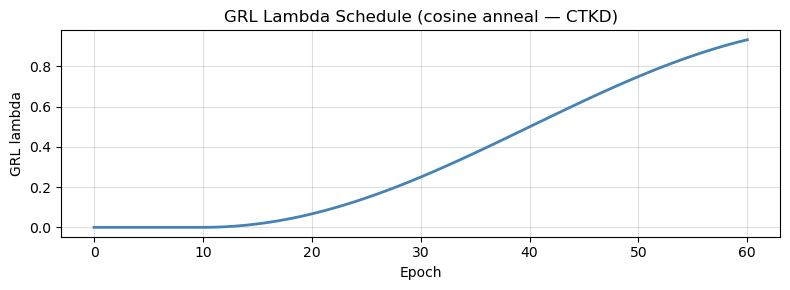

lambda at epoch   0 : 0.0000
lambda at epoch   15 : 0.0170
lambda at epoch   30 : 0.2500
lambda at epoch  60 : 0.9330


In [7]:
class GradientReversalFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, grl_lambda):
        ctx.save_for_backward(torch.tensor(grl_lambda))
        return x.clone()

    @staticmethod
    def backward(ctx, grad_output):
        grl_lambda, = ctx.saved_tensors
        return -grl_lambda.item() * grad_output, None


def grad_reverse(x, grl_lambda):
    return GradientReversalFunction.apply(x, grl_lambda)


def compute_grl_lambda(epoch, total_epochs, lambda_max=GRL_LAMBDA_MAX):
    """Cosine-annealed GRL schedule from CTKD (Li et al., ECCV 2022)."""
    epoch = max(0, epoch - 10) # warmup for 10 epochs (lambda=0 -> no GRL effect)
    progress = min(epoch, total_epochs) / total_epochs
    return 0.5 * lambda_max * (1 - np.cos(np.pi * progress))


ep_range = np.arange(0, EPOCHS + 1)
lambdas  = [compute_grl_lambda(e, EPOCHS) for e in ep_range]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(ep_range, lambdas, color='steelblue', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('GRL lambda')
ax.set_title('GRL Lambda Schedule (cosine anneal — CTKD)')
ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

print(f'lambda at epoch   0 : {compute_grl_lambda(0,          EPOCHS):.4f}')
print(f'lambda at epoch  {EPOCHS//4:3d} : {compute_grl_lambda(EPOCHS//4,  EPOCHS):.4f}')
print(f'lambda at epoch  {EPOCHS//2:3d} : {compute_grl_lambda(EPOCHS//2,  EPOCHS):.4f}')
print(f'lambda at epoch {EPOCHS:3d} : {compute_grl_lambda(EPOCHS,     EPOCHS):.4f}')


## 6. Dual MLP Learnable Temperature Module

Each temperature is produced by a **three-layer MLP** (two hidden layers) that takes
the **batch-mean student logits** $\bar{z}^S \in \mathbb{R}^C$ as input and outputs a
scalar $\phi$, which is sigmoid-constrained to $[\tau_{min}, \tau_{max}]$:

$$\tau = \tau_{min} + (\tau_{max} - \tau_{min}) \cdot \sigma(\phi), \quad
\phi = \mathrm{MLP}(\bar{z}^S)$$

Architecture per head (input dim $C$ = `NUM_CLASSES` = 38):
```
Linear(C, H) → ReLU → Linear(H, H) → ReLU → Linear(H, 1)
```
where `H = MLP_HIDDEN_DIM`.

Using the **student logits** as input lets each MLP sense the student's current
prediction confidence and class distribution — much richer than a scalar epoch counter.
Both temperatures adapt dynamically **per batch** based on what the student
actually knows right now, not just when in training it is.

Two **independent** MLP heads — `mlp_tckd` and `mlp_nckd` — let the two DKD components
learn distinct temperature responses to the same logit signal.

The GRL is applied to $\phi$ before the sigmoid constraint, so both temperatures are
driven adversarially while the student minimises the distillation losses.

Both heads are initialised so that $\tau \approx 4.0$ at the start of training
(classical KD starting point).


In [8]:
class DualTemperatureModule(nn.Module):
    """
    Two independently learnable temperature heads for TCKD and NCKD.

    Each temperature is produced by a 3-layer MLP (two hidden layers):
        input  : mean-pooled student logits, shape (C,)  [batch mean of (B, C)]
        layer1 : Linear(C, H) -> ReLU
        layer2 : Linear(H, H) -> ReLU
        output : Linear(H, 1) -> scalar phi
        constrained: tau = tau_min + (tau_max - tau_min) * sigmoid(phi)

    Using student logits as input lets the MLP sense current prediction confidence
    and adapt temperatures per-batch, not just per-epoch.

    GRL is applied to phi before the sigmoid so both temperatures are pushed
    adversarially to maximise the distillation losses (student minimises them).
    """

    def __init__(self, num_classes=NUM_CLASSES, tau_min=TAU_MIN, tau_max=TAU_MAX,
                 hidden_dim=MLP_HIDDEN_DIM):
        super().__init__()
        self.tau_min = tau_min
        self.tau_max = tau_max

        # MLP for TCKD temperature: C -> H -> H -> 1
        self.mlp_tckd = nn.Sequential(
            nn.Linear(num_classes, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

        # MLP for NCKD temperature: C -> H -> H -> 1
        self.mlp_nckd = nn.Sequential(
            nn.Linear(num_classes, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

        # Initialise both heads so that tau ≈ 4.0 at the start of training.
        # Set the output-layer bias = inverse_sigmoid((4.0 - tau_min)/(tau_max - tau_min))
        # and zero everything else, so MLP(any input) ≈ init_phi at init.
        init_ratio = (4.0 - tau_min) / (tau_max - tau_min)
        init_phi   = float(np.log(init_ratio / (1.0 - init_ratio)))  # inverse sigmoid

        for mlp in (self.mlp_tckd, self.mlp_nckd):
            for layer in mlp:
                if isinstance(layer, nn.Linear):
                    nn.init.zeros_(layer.weight)
                    nn.init.zeros_(layer.bias)
            nn.init.constant_(mlp[-1].bias, init_phi)  # output layer bias

    def _constrain(self, phi):
        """Sigmoid-squash scalar/tensor phi into [tau_min, tau_max]."""
        return self.tau_min + (self.tau_max - self.tau_min) * torch.sigmoid(phi)

    def _run_mlp(self, mlp, s_logits):
        """Pool s_logits (B, C) -> mean over batch -> (1, C), run MLP -> scalar phi."""
        feat = s_logits.detach().mean(dim=0, keepdim=True)   # (1, C) — detach: no grad to student
        return mlp(feat).squeeze()                            # scalar tensor

    def tau_tckd(self, s_logits):
        """Current TCKD temperature (no GRL, for logging). Expects s_logits (B, C)."""
        with torch.no_grad():
            phi = self._run_mlp(self.mlp_tckd, s_logits)
        return self._constrain(phi)

    def tau_nckd(self, s_logits):
        """Current NCKD temperature (no GRL, for logging). Expects s_logits (B, C)."""
        with torch.no_grad():
            phi = self._run_mlp(self.mlp_nckd, s_logits)
        return self._constrain(phi)

    def forward(self, s_logits, grl_lambda):
        """Returns (tau_tckd, tau_nckd) with GRL applied for adversarial update.

        Args:
            s_logits   : (B, C) student logits — used as MLP input (batch-mean)
            grl_lambda : float  — current GRL reversal strength
        """
        phi_t = self._run_mlp(self.mlp_tckd, s_logits)   # scalar, grad flows to mlp_tckd
        phi_n = self._run_mlp(self.mlp_nckd, s_logits)   # scalar, grad flows to mlp_nckd

        # GRL reverses gradients flowing back into each MLP
        phi_t = grad_reverse(phi_t, grl_lambda)
        phi_n = grad_reverse(phi_n, grl_lambda)

        return self._constrain(phi_t), self._constrain(phi_n)


# Instantiate and verify initial temperatures
temp_module = DualTemperatureModule(NUM_CLASSES, TAU_MIN, TAU_MAX, MLP_HIDDEN_DIM).to(DEVICE)

_dummy_logits = torch.zeros(4, NUM_CLASSES).to(DEVICE)
print('DualTemperatureModule (MLP, 2 hidden layers) initialised.')
print(f'  tau_tckd at init : {temp_module.tau_tckd(_dummy_logits).item():.4f}  (target: 4.0)')
print(f'  tau_nckd at init : {temp_module.tau_nckd(_dummy_logits).item():.4f}  (target: 4.0)')
print(f'  tau range        : [{TAU_MIN}, {TAU_MAX}]')
print(f'  MLP architecture : Linear({NUM_CLASSES}, {MLP_HIDDEN_DIM}) -> ReLU -> '
      f'Linear({MLP_HIDDEN_DIM}, {MLP_HIDDEN_DIM}) -> ReLU -> Linear({MLP_HIDDEN_DIM}, 1)')
total_temp_params = sum(p.numel() for p in temp_module.parameters())
print(f'  Trainable params : {total_temp_params}  '
      f'(mlp_tckd: {sum(p.numel() for p in temp_module.mlp_tckd.parameters())}  '
      f'mlp_nckd: {sum(p.numel() for p in temp_module.mlp_nckd.parameters())})')


DualTemperatureModule (MLP, 2 hidden layers) initialised.
  tau_tckd at init : 4.0000  (target: 4.0)
  tau_nckd at init : 4.0000  (target: 4.0)
  tau range        : [2.0, 10.0]
  MLP architecture : Linear(38, 64) -> ReLU -> Linear(64, 64) -> ReLU -> Linear(64, 1)
  Trainable params : 13442  (mlp_tckd: 6721  mlp_nckd: 6721)


## 7. DKD Loss with Dual Learnable Temperatures

TCKD uses binary-distribution BCE at $\tau_{TCKD}$; NCKD uses KL over non-target classes
at $\tau_{NCKD}$.


In [ ]:
class DKDDualTempLoss(nn.Module):
    """
    DKD loss with independently learnable temperatures for TCKD and NCKD.

    CE is computed via criterion_ce (label_smoothing=0.1) passed in from the caller,
    matching the retrained baseline where label-smoothed CE is used throughout.

    Args:
        alpha : weight on TCKD loss  (default 1.0)
        beta  : weight on NCKD loss  (default 8.0)

    Forward:
        s_logits    : (B, C) student logits
        t_logits    : (B, C) teacher logits  (no_grad expected from caller)
        labels      : (B,)   integer ground-truth labels
        tau_tckd    : scalar tensor -- temperature for TCKD (with GRL applied)
        tau_nckd    : scalar tensor -- temperature for NCKD (with GRL applied)
        criterion_ce: nn.CrossEntropyLoss(label_smoothing=0.1) -- passed in

    Returns:
        total_loss, tckd_loss (detached), nckd_loss (detached), ce_loss (detached)
    """

    def __init__(self, alpha=ALPHA, beta=BETA):
        super().__init__()
        self.alpha = alpha
        self.beta  = beta

    @staticmethod
    def _split_logits(logits, labels):
        B, C    = logits.shape
        gt_mask = F.one_hot(labels, C).bool()
        tgt     = logits[gt_mask].unsqueeze(1)      # (B, 1)
        rest    = logits[~gt_mask].view(B, C - 1)   # (B, C-1)
        return tgt, rest

    # def forward(self, s_logits, t_logits, labels, tau_tckd, tau_nckd, criterion_ce):
    #     ce_loss = criterion_ce(s_logits, labels)

    #     s_tgt, s_rest = self._split_logits(s_logits, labels)
    #     t_tgt, t_rest = self._split_logits(t_logits, labels)

    #     # -- TCKD: binary distribution BCE ------------------------------------
    #     s_bin = torch.cat([s_tgt, s_rest.logsumexp(dim=1, keepdim=True)], dim=1)
    #     t_bin = torch.cat([t_tgt, t_rest.logsumexp(dim=1, keepdim=True)], dim=1)

    #     s_bin_prob = torch.softmax(s_bin / tau_tckd, dim=1)
    #     t_bin_prob = torch.softmax(t_bin / tau_tckd, dim=1)
    #     tckd_loss  = -(t_bin_prob * torch.log(s_bin_prob + 1e-8)).sum(dim=1).mean()

    #     # -- NCKD: KL over non-target classes ---------------------------------
    #     s_nckd    = F.log_softmax(s_rest / tau_nckd, dim=1)
    #     t_nckd    = F.softmax(t_rest    / tau_nckd, dim=1)
    #     nckd_loss = F.kl_div(s_nckd, t_nckd, reduction='batchmean')

    #     # total = CE + alpha*TCKD + beta*NCKD
    #     total = ce_loss + self.alpha * tckd_loss + self.beta * nckd_loss

    #     return total, tckd_loss.detach(), nckd_loss.detach(), ce_loss.detach()
    def forward(self, s_logits, t_logits, labels, tau_tckd, tau_nckd, criterion_ce):
        ce_loss = criterion_ce(s_logits, labels)

        s_tgt, s_rest = self._split_logits(s_logits, labels)
        t_tgt, t_rest = self._split_logits(t_logits, labels)

        # -- TCKD: binary distribution BCE ------------------------------------
        s_bin = torch.cat([s_tgt, s_rest.logsumexp(dim=1, keepdim=True)], dim=1)
        t_bin = torch.cat([t_tgt, t_rest.logsumexp(dim=1, keepdim=True)], dim=1)

        # FIX 1: Use log_softmax for the student for numerical stability
        s_bin_log_prob = F.log_softmax(s_bin / tau_tckd, dim=1)
        t_bin_prob     = F.softmax(t_bin / tau_tckd, dim=1)
        
        # Manual CE using the stable log probabilities
        tckd_loss = -(t_bin_prob * s_bin_log_prob).sum(dim=1).mean()

        # -- NCKD: KL over non-target classes ---------------------------------
        s_nckd    = F.log_softmax(s_rest / tau_nckd, dim=1)
        t_nckd    = F.softmax(t_rest / tau_nckd, dim=1)
        nckd_loss = F.kl_div(s_nckd, t_nckd, reduction='batchmean')

        # FIX 2: Apply tau^2 scaling to both KD loss components
        scaled_tckd = (tau_tckd ** 2) * tckd_loss
        scaled_nckd = (tau_nckd ** 2) * nckd_loss

        # total = CE + alpha*(tau^2)*TCKD + beta*(tau^2)*NCKD
        total = ce_loss + self.alpha * scaled_tckd + self.beta * scaled_nckd

        return total, tckd_loss.detach(), nckd_loss.detach(), ce_loss.detach()

criterion_ce = nn.CrossEntropyLoss(label_smoothing=0.1)
criterion     = DKDDualTempLoss(alpha=ALPHA, beta=BETA)

print('DKDDualTempLoss instantiated.')
print(f'  alpha (TCKD weight) : {criterion.alpha}')
print(f'  beta  (NCKD weight) : {criterion.beta}')
print(f'  CE    (label smooth): label_smoothing=0.1')


DKDDualTempLoss instantiated.
  alpha (TCKD weight) : 0.5
  beta  (NCKD weight) : 10.0
  CE    (label smooth): label_smoothing=0.1


## 8. Optimiser and Scheduler

SGD + Nesterov, CosineAnnealingLR — identical to the retrained baseline notebooks.
Temperature parameters are placed in a separate param group with their own LR so they are
unaffected by the student's cosine decay.


In [10]:
student_params = list(student.parameters())
temp_params    = list(temp_module.parameters())  # includes both MLP heads

optimizer = torch.optim.SGD([
    {'params': student_params, 'lr': LR},
    {'params': temp_params,    'lr': LR_TEMP},
], momentum=MOMENTUM, weight_decay=WEIGHT_DECAY, nesterov=True)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-4
)

print('Optimiser and scheduler configured.')
print(f'  Optimiser    : SGD (Nesterov)  student lr={LR}  temp lr={LR_TEMP}')
print(f'  Scheduler    : CosineAnnealingLR  T_max={EPOCHS}  eta_min=1e-4')
print(f'  WD           : {WEIGHT_DECAY}')
print(f'  Student params  : {sum(p.numel() for p in student_params)/1e6:.2f}M')
print(f'  Temp MLP params : {sum(p.numel() for p in temp_params)}')
print(f'    mlp_tckd      : {sum(p.numel() for p in temp_module.mlp_tckd.parameters())}')
print(f'    mlp_nckd      : {sum(p.numel() for p in temp_module.mlp_nckd.parameters())}')


Optimiser and scheduler configured.
  Optimiser    : SGD (Nesterov)  student lr=0.075  temp lr=0.0001
  Scheduler    : CosineAnnealingLR  T_max=60  eta_min=1e-4
  WD           : 0.0001
  Student params  : 2.27M
  Temp MLP params : 13442
    mlp_tckd      : 6721
    mlp_nckd      : 6721


## 9. Evaluation Utility

In [11]:
@torch.no_grad()
def evaluate(model, loader, device):
    """Top-1 and Top-5 accuracy."""
    model.eval()
    top1_c = top5_c = total = 0
    for imgs, labels in tqdm(loader, desc='Eval', leave=False, dynamic_ncols=True):
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        top1_c += (logits.argmax(1) == labels).sum().item()
        top5_c += (logits.topk(5, dim=1).indices == labels.unsqueeze(1)).any(1).sum().item()
        total  += labels.size(0)
    return 100.0 * top1_c / total, 100.0 * top5_c / total

print('evaluate() ready -- returns (top1 %, top5 %).')


evaluate() ready -- returns (top1 %, top5 %).


## 10. Training Loop

In [12]:
def train_one_epoch(student, teacher, temp_module, criterion, criterion_ce,
                    optimizer, loader, grl_lambda, device, epoch, total_epochs):
    """One epoch of DKD + dual-MLP-temp adversarial training. Returns dict of averaged metrics."""
    student.train()
    teacher.eval()
    for p in teacher.parameters():
        p.requires_grad_(False)
    temp_module.train()

    sums = dict(total=0., tckd=0., nckd=0., ce=0., correct=0, n=0)
    last_s_logits = None
    pbar = tqdm(loader, desc=f'Ep {epoch:3d}/{total_epochs}', leave=False, dynamic_ncols=True)

    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        B = imgs.size(0)

        with torch.no_grad():
            t_logits = teacher(imgs)

        optimizer.zero_grad()
        s_logits = student(imgs)

        # GRL disabled for first 5 epochs for stable warmup
        effective_lambda = grl_lambda if epoch > 5 else 0.0

        # MLP produces temperature conditioned on student logits (batch-mean)
        tau_t, tau_n = temp_module(s_logits, effective_lambda)

        total_loss, tckd_l, nckd_l, ce_l = criterion(
            s_logits, t_logits, labels, tau_t, tau_n, criterion_ce
        )
        total_loss.backward()
        optimizer.step()

        sums['total']   += total_loss.item() * B
        sums['tckd']    += tckd_l.item()     * B
        sums['nckd']    += nckd_l.item()     * B
        sums['ce']      += ce_l.item()        * B
        sums['correct'] += (s_logits.argmax(1) == labels).sum().item()
        sums['n']       += B
        last_s_logits    = s_logits.detach()

        pbar.set_postfix(
            loss=f'{total_loss.item():.3f}',
            tau_t=f'{tau_t.item():.2f}',
            tau_n=f'{tau_n.item():.2f}',
        )

    n = sums['n']
    return {
        'total_loss' : sums['total'] / n,
        'tckd_loss'  : sums['tckd'] / n,
        'nckd_loss'  : sums['nckd'] / n,
        'ce_loss'    : sums['ce']   / n,
        'train_acc'  : 100.0 * sums['correct'] / n,
        'tau_tckd'   : temp_module.tau_tckd(last_s_logits).item(),
        'tau_nckd'   : temp_module.tau_nckd(last_s_logits).item(),
        'grl_lambda' : grl_lambda,
    }

print('train_one_epoch() defined.')


train_one_epoch() defined.


## 11. Training Run

In [13]:
history = {
    'epoch': [], 'total_loss': [], 'tckd_loss': [], 'nckd_loss': [], 'ce_loss': [],
    'train_acc': [], 'val_top1': [], 'val_top5': [],
    'tau_tckd': [], 'tau_nckd': [], 'grl_lambda': [],
}

best_top1  = 0.0
best_epoch = 0

print('Starting DKD + Dual MLP Learnable Temperature training on PlantVillage...')
print(f'  Epochs         : {EPOCHS}')
print(f'  alpha / beta   : {ALPHA} / {BETA}')
print(f'  tau range      : [{TAU_MIN}, {TAU_MAX}]')
print(f'  MLP hidden dim : {MLP_HIDDEN_DIM}  (per head)')
_init_logits = torch.zeros(4, NUM_CLASSES).to(DEVICE)
print(f'  Initial tau    : {temp_module.tau_tckd(_init_logits).item():.2f} (TCKD)  '
      f'{temp_module.tau_nckd(_init_logits).item():.2f} (NCKD)')
print(f'  CE smoothing   : 0.1')
print('-' * 90)

for epoch in range(1, EPOCHS + 1):
    grl_lambda = compute_grl_lambda(epoch, EPOCHS, GRL_LAMBDA_MAX)

    metrics = train_one_epoch(
        student, teacher, temp_module, criterion, criterion_ce,
        optimizer, train_loader, grl_lambda, DEVICE, epoch, EPOCHS
    )
    val_top1, val_top5 = evaluate(student, val_loader, DEVICE)
    scheduler.step()

    history['epoch'].append(epoch)
    history['total_loss'].append(metrics['total_loss'])
    history['tckd_loss'].append(metrics['tckd_loss'])
    history['nckd_loss'].append(metrics['nckd_loss'])
    history['ce_loss'].append(metrics['ce_loss'])
    history['train_acc'].append(metrics['train_acc'])
    history['val_top1'].append(val_top1)
    history['val_top5'].append(val_top5)
    history['tau_tckd'].append(metrics['tau_tckd'])
    history['tau_nckd'].append(metrics['tau_nckd'])
    history['grl_lambda'].append(grl_lambda)

    if val_top1 > best_top1:
        best_top1  = val_top1
        best_epoch = epoch
        torch.save({
            'state_dict'    : student.state_dict(),
            'temp_state'    : temp_module.state_dict(),
            'epoch'         : epoch,
            'val_top1'      : val_top1,
            'val_top5'      : val_top5,
            'tau_tckd'      : metrics['tau_tckd'],
            'tau_nckd'      : metrics['tau_nckd'],
            'alpha'         : ALPHA,
            'beta'          : BETA,
            'lr'            : LR,
            'wd'            : WEIGHT_DECAY,
            'label_smoothing': 0.1,
            'scheduler'     : 'CosineAnnealingLR',
            'mlp_hidden_dim': MLP_HIDDEN_DIM,
            'num_classes'   : NUM_CLASSES,
            'img_size'      : IMG_SIZE,
        }, CKPT_DIR / 'pv_b7_mobilenetv2_dkd_dual_mlp_temp_v6.pth')

    if epoch < 10 or epoch % 5 == 0 or epoch == EPOCHS:
        current_lr = scheduler.get_last_lr()[0]
        print(
            f'Ep {epoch:3d}/{EPOCHS} | '
            f'loss {metrics["total_loss"]:6.3f} '
            f'(tckd {metrics["tckd_loss"]:5.3f} | nckd {metrics["nckd_loss"]:5.3f} | ce {metrics["ce_loss"]:5.3f}) | '
            f'train {metrics["train_acc"]:5.2f}% | '
            f'val top1 {val_top1:5.2f}% top5 {val_top5:4.2f}% | '
            f'tau_t {metrics["tau_tckd"]:4.2f} tau_n {metrics["tau_nckd"]:4.2f} | '
            f'lambda {grl_lambda:.3f} | lr {current_lr:.5f}'
            + (' [*]' if val_top1 == best_top1 else '')
        )

print('-' * 90)
print(f'Training complete.')
print(f'  Best val Top-1  : {best_top1:.2f}%  (epoch {best_epoch})')
print(f'  Checkpoint      : pv_b7_mobilenetv2_dkd_dual_mlp_temp_v6.pth')
print(f'  tau_TCKD at best epoch : {history["tau_tckd"][best_epoch-1]:.4f}')
print(f'  tau_NCKD at best epoch : {history["tau_nckd"][best_epoch-1]:.4f}')
print(f'  Final tau_TCKD  : {history["tau_tckd"][-1]:.4f}')
print(f'  Final tau_NCKD  : {history["tau_nckd"][-1]:.4f}')
print(f'  Final divergence: {history["tau_tckd"][-1] - history["tau_nckd"][-1]:+.4f}')

with open(CKPT_DIR / 'pv_dkd_dual_mlp_temp_training_history.json', 'w') as f:
    json.dump(history, f, indent=2)
print('Training history saved.')


Starting DKD + Dual MLP Learnable Temperature training on PlantVillage...
  Epochs         : 60
  alpha / beta   : 0.5 / 10.0
  tau range      : [2.0, 10.0]
  MLP hidden dim : 64  (per head)


  Initial tau    : 4.00 (TCKD)  4.00 (NCKD)
  CE smoothing   : 0.1
------------------------------------------------------------------------------------------


Ep   1/60 | loss  2.751 (tckd 0.729 | nckd 0.024 | ce 2.144) | train 52.12% | val top1 62.91% top5 90.29% | tau_t 4.00 tau_n 4.00 | lambda 0.000 | lr 0.07495 [*]


Ep   2/60 | loss  1.825 (tckd 0.716 | nckd 0.017 | ce 1.292) | train 79.38% | val top1 70.02% top5 96.17% | tau_t 4.00 tau_n 4.00 | lambda 0.000 | lr 0.07479 [*]


Ep   3/60 | loss  1.559 (tckd 0.719 | nckd 0.013 | ce 1.066) | train 87.14% | val top1 82.21% top5 98.12% | tau_t 4.00 tau_n 4.00 | lambda 0.000 | lr 0.07454 [*]


...

Ep  40/60 | loss  1.130 (tckd 0.729 | nckd 0.006 | ce 0.707) | train 99.34% | val top1 98.84% top5 99.91% | tau_t 3.93 tau_n 3.73 | lambda 0.500 | lr 0.01883


Ep  45/60 | loss  1.121 (tckd 0.730 | nckd 0.006 | ce 0.698) | train 99.64% | val top1 99.08% top5 99.98% | tau_t 3.89 tau_n 3.61 | lambda 0.629 | lr 0.01107


Ep  50/60 | loss  1.119 (tckd 0.731 | nckd 0.006 | ce 0.695) | train 99.76% | val top1 99.36% top5 99.98% | tau_t 3.85 tau_n 3.47 | lambda 0.750 | lr 0.00512


Ep  55/60 | loss  1.122 (tckd 0.732 | nckd 0.006 | ce 0.693) | train 99.85% | val top1 99.47% top5 99.98% | tau_t 3.79 tau_n 3.32 | lambda 0.854 | lr 0.00138


Ep  60/60 | loss  1.128 (tckd 0.733 | nckd 0.007 | ce 0.693) | train 99.85% | val top1 99.39% top5 99.96% | tau_t 3.74 tau_n 3.17 | lambda 0.933 | lr 0.00010
------------------------------------------------------------------------------------------
Training complete.
  Best val Top-1  : 99.50%  (epoch 54)
  Checkpoint      : pv_b7_mobilenetv2_dkd_dual_mlp_temp_v6.pth
  tau_TCKD at best epoch : 3.8050
  tau_NCKD at best epoch : 3.3551
  Final tau_TCKD  : 3.7353
  Final tau_NCKD  : 3.1679
  Final divergence: +0.5674
Training history saved.


## 12. Final Evaluation on Test Set

In [14]:
best_ckpt = torch.load(CKPT_DIR / 'pv_b7_mobilenetv2_dkd_dual_mlp_temp_v6.pth', map_location=DEVICE)
student.load_state_dict(best_ckpt['state_dict'])

test_top1, test_top5 = evaluate(student, test_loader, DEVICE)
print(f'B7 DKD + Dual MLP Temp — Test Top-1: {test_top1:.2f}%  Top-5: {test_top5:.2f}%')

# Update checkpoint with test results
best_ckpt['test_top1'] = float(test_top1)
best_ckpt['test_top5'] = float(test_top5)
torch.save(best_ckpt, CKPT_DIR / 'pv_b7_mobilenetv2_dkd_dual_mlp_temp_v6.pth')
print('Checkpoint updated with test results.')


B7 DKD + Dual MLP Temp — Test Top-1: 99.54%  Top-5: 99.89%
Checkpoint updated with test results.


## 13. Training Visualisations

### 13.1 Accuracy and Loss Curves

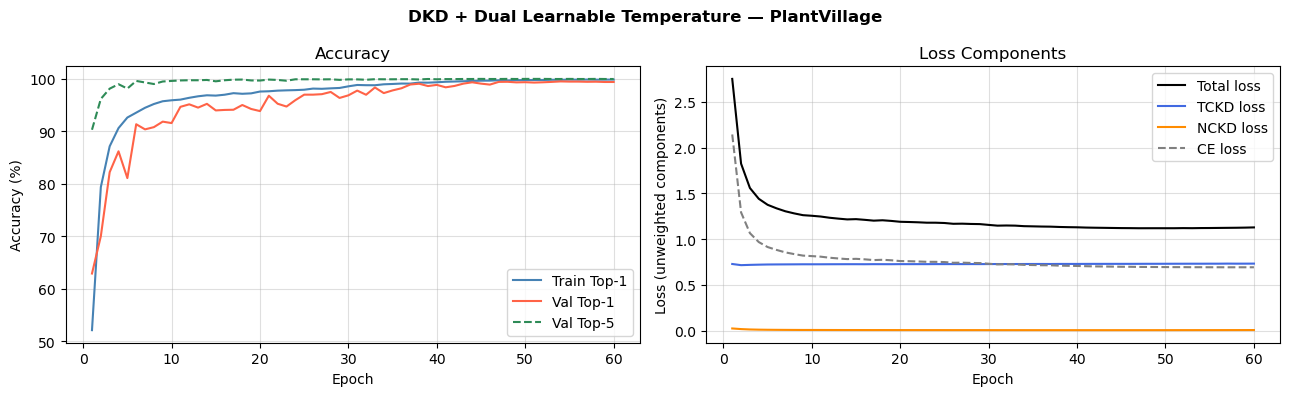

Curve data saved -> checkpoints/pv_dkd_dual_temp_accuracy_loss_curves.json


In [15]:
ep = history['epoch']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('DKD + Dual Learnable Temperature — PlantVillage', fontweight='bold')

axes[0].plot(ep, history['train_acc'], label='Train Top-1', color='steelblue')
axes[0].plot(ep, history['val_top1'], label='Val Top-1',   color='tomato')
axes[0].plot(ep, history['val_top5'], label='Val Top-5',   color='seagreen', linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].plot(ep, history['total_loss'], label='Total loss',  color='black')
axes[1].plot(ep, history['tckd_loss'],  label='TCKD loss',   color='royalblue')
axes[1].plot(ep, history['nckd_loss'],  label='NCKD loss',   color='darkorange')
axes[1].plot(ep, history['ce_loss'],    label='CE loss',     color='gray', linestyle='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss (unweighted components)')
axes[1].set_title('Loss Components'); axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.tight_layout(); plt.show()

with open(CKPT_DIR / 'pv_dkd_dual_temp_accuracy_loss_curves.json', 'w') as f:
    json.dump({'epoch': history['epoch'], 'train_acc': history['train_acc'],
               'val_top1': history['val_top1'], 'val_top5': history['val_top5'],
               'total_loss': history['total_loss'], 'tckd_loss': history['tckd_loss'],
               'nckd_loss': history['nckd_loss'], 'ce_loss': history['ce_loss']}, f, indent=2)
print(f'Curve data saved -> {CKPT_DIR / "pv_dkd_dual_temp_accuracy_loss_curves.json"}')


### 13.2 Temperature Curriculum

The central diagnostic: do $\tau_{TCKD}$ and $\tau_{NCKD}$ evolve differently?

- If they **diverge**: the two DKD components require different temperature scales, validating the dual-temperature design.
- If $\tau_{TCKD}$ rises and $\tau_{NCKD}$ falls (or vice versa): the GRL is finding asymmetric optima.
- If they stay flat: consider increasing `LR_TEMP` or `GRL_LAMBDA_MAX`.


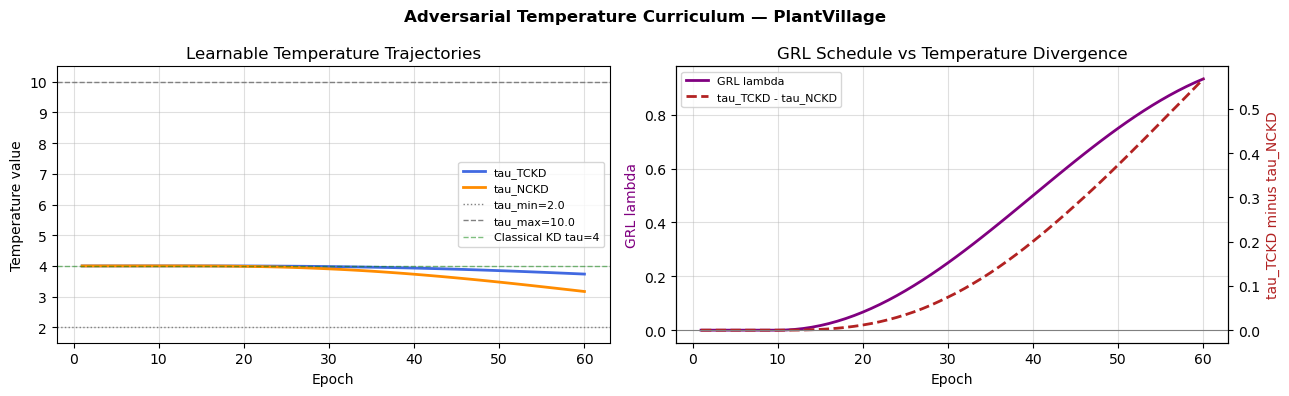

Temperature curriculum interpretation:
  Initial tau_TCKD : ~4.00  ->  Final: 3.735
  Initial tau_NCKD : ~4.00  ->  Final: 3.168
  Final divergence (TCKD - NCKD) : +0.567
Temperature data saved -> checkpoints/pv_dkd_dual_temp_temperature_curriculum.json


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Adversarial Temperature Curriculum — PlantVillage', fontweight='bold')

axes[0].plot(ep, history['tau_tckd'], label='tau_TCKD', color='royalblue', linewidth=2)
axes[0].plot(ep, history['tau_nckd'], label='tau_NCKD', color='darkorange', linewidth=2)
axes[0].axhline(TAU_MIN, color='gray', linestyle=':', linewidth=1, label=f'tau_min={TAU_MIN}')
axes[0].axhline(TAU_MAX, color='gray', linestyle='--', linewidth=1, label=f'tau_max={TAU_MAX}')
axes[0].axhline(4.0, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Classical KD tau=4')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Temperature value')
axes[0].set_title('Learnable Temperature Trajectories')
axes[0].set_ylim(TAU_MIN - 0.5, TAU_MAX + 0.5)
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.4)

ax2  = axes[1]
ax2b = ax2.twinx()
tau_diff = [t - n for t, n in zip(history['tau_tckd'], history['tau_nckd'])]
ax2.plot(ep,  history['grl_lambda'], color='purple',   linewidth=2, label='GRL lambda')
ax2b.plot(ep, tau_diff,              color='firebrick', linewidth=2, linestyle='--', label='tau_TCKD - tau_NCKD')
ax2b.axhline(0, color='gray', linewidth=0.8)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('GRL lambda', color='purple')
ax2b.set_ylabel('tau_TCKD minus tau_NCKD', color='firebrick')
ax2.set_title('GRL Schedule vs Temperature Divergence')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
ax2.grid(True, alpha=0.4)

plt.tight_layout(); plt.show()

print('Temperature curriculum interpretation:')
print(f'  Initial tau_TCKD : ~4.00  ->  Final: {history["tau_tckd"][-1]:.3f}')
print(f'  Initial tau_NCKD : ~4.00  ->  Final: {history["tau_nckd"][-1]:.3f}')
print(f'  Final divergence (TCKD - NCKD) : {history["tau_tckd"][-1] - history["tau_nckd"][-1]:+.3f}')

with open(CKPT_DIR / 'pv_dkd_dual_temp_temperature_curriculum.json', 'w') as f:
    json.dump({'epoch': history['epoch'], 'tau_tckd': history['tau_tckd'],
               'tau_nckd': history['tau_nckd'], 'tau_diff': tau_diff,
               'grl_lambda': history['grl_lambda'],
               'tau_min': float(TAU_MIN), 'tau_max': float(TAU_MAX)}, f, indent=2)
print(f'Temperature data saved -> {CKPT_DIR / "pv_dkd_dual_temp_temperature_curriculum.json"}')


## 14. Results Summary

In [17]:
baseline_results = {
    'Teacher ResNet-18'             : {'val_top1': str(teacher_top1), 'test_top1': None, 'note': 'Teacher ceiling'},
    'B2 MobileNetV2 Vanilla'        : {'val_top1': None, 'test_top1': None, 'note': 'Student w/o KD'},
    'B3 MobileNetV2 + Classical KD' : {'val_top1': None, 'test_top1': None, 'note': 'Primary baseline'},
    'B4 DKD (fixed tau)'            : {'val_top1': None, 'test_top1': None, 'note': 'DKD fixed tau'},
}

for ckpt_file, key in [
    ('pv_b2_mobilenetv2_vanilla.pth', 'B2 MobileNetV2 Vanilla'),
    ('pv_b3_mobilenetv2_kd.pth',      'B3 MobileNetV2 + Classical KD'),
    ('pv_b4_mobilenetv2_dkd.pth',     'B4 DKD (fixed tau)'),
]:
    path = CKPT_DIR / ckpt_file
    if path.exists():
        ckpt = torch.load(path, map_location='cpu')
        t1      = ckpt.get('val_top1', ckpt.get('top1', None))
        t1_test = ckpt.get('test_top1', None)
        if t1:
            baseline_results[key]['val_top1']  = round(t1, 2)
        if t1_test:
            baseline_results[key]['test_top1'] = round(t1_test, 2)

rows = [{'Model': k, 'Val Top-1 (%)': v['val_top1'], 'Test Top-1 (%)': v['test_top1'], 'Note': v['note']}
        for k, v in baseline_results.items()]
rows.append({
    'Model'          : 'B7 DKD + Dual MLP Temp (ours)',
    'Val Top-1 (%)' : round(best_top1, 2),
    'Test Top-1 (%)': round(test_top1, 2),
    'Note'           : (f'Best epoch {best_epoch}  |  '
                        f'tau_TCKD={history["tau_tckd"][best_epoch-1]:.2f}  '
                        f'tau_NCKD={history["tau_nckd"][best_epoch-1]:.2f}  '
                        f'label_smooth=0.1'),
})

df = pd.DataFrame(rows)
print('=' * 84)
print('PLANTVILLAGE RESULTS — DKD + DUAL LEARNABLE TEMPERATURES')
print('=' * 84)
print(df.to_string(index=False))
print('=' * 84)

b3_top1 = baseline_results['B3 MobileNetV2 + Classical KD']['val_top1']
if b3_top1 is not None:
    print(f'\nGain vs classical KD (B7 - B3) val  : {best_top1 - b3_top1:+.2f}%')

b3_test = baseline_results['B3 MobileNetV2 + Classical KD']['test_top1']
if b3_test is not None:
    print(f'Gain vs classical KD (B7 - B3) test : {test_top1 - b3_test:+.2f}%')

with open(CKPT_DIR / 'pv_dkd_dual_mlp_temp_results_summary.json', 'w') as f:
    json.dump({'baseline_results': baseline_results,
               'best': {'val_top1': round(best_top1, 2),
                        'val_top5': round(history['val_top5'][best_epoch-1], 2),
                        'test_top1': round(test_top1, 2),
                        'test_top5': round(test_top5, 2),
                        'epoch': best_epoch,
                        'tau_tckd': history['tau_tckd'][best_epoch-1],
                        'tau_nckd': history['tau_nckd'][best_epoch-1]}}, f, indent=2)
print(f'Results saved -> {CKPT_DIR / "pv_dkd_dual_mlp_temp_results_summary.json"}')


PLANTVILLAGE RESULTS — DKD + DUAL LEARNABLE TEMPERATURES
                        Model     Val Top-1 (%)  Test Top-1 (%)                                                             Note
            Teacher ResNet-18 99.92633517495396             NaN                                                  Teacher ceiling
       B2 MobileNetV2 Vanilla             99.47             NaN                                                   Student w/o KD
B3 MobileNetV2 + Classical KD             99.91             NaN                                                 Primary baseline
           B4 DKD (fixed tau)              None             NaN                                                    DKD fixed tau
B7 DKD + Dual MLP Temp (ours)              99.5           99.54 Best epoch 54  |  tau_TCKD=3.81  tau_NCKD=3.36  label_smooth=0.1

Gain vs classical KD (B7 - B3) val  : -0.41%
Results saved -> checkpoints/pv_dkd_dual_mlp_temp_results_summary.json


## 15. Full Training History Table

In [18]:
df_hist = pd.DataFrame({
    'Epoch'      : history['epoch'],
    'Total Loss' : [f'{v:.4f}' for v in history['total_loss']],
    'TCKD Loss'  : [f'{v:.4f}' for v in history['tckd_loss']],
    'NCKD Loss'  : [f'{v:.4f}' for v in history['nckd_loss']],
    'CE Loss'    : [f'{v:.4f}' for v in history['ce_loss']],
    'Train Acc'  : [f'{v:.2f}%' for v in history['train_acc']],
    'Val Top-1'  : [f'{v:.2f}%' for v in history['val_top1']],
    'Val Top-5'  : [f'{v:.2f}%' for v in history['val_top5']],
    'tau_TCKD'   : [f'{v:.3f}' for v in history['tau_tckd']],
    'tau_NCKD'   : [f'{v:.3f}' for v in history['tau_nckd']],
    'GRL lambda' : [f'{v:.3f}' for v in history['grl_lambda']],
})
print(df_hist.to_string(index=False))

with open(CKPT_DIR / 'pv_dkd_dual_temp_epoch_history.json', 'w') as f:
    json.dump(history, f, indent=2)
print(f'\nEpoch-by-epoch history saved -> {CKPT_DIR / "pv_dkd_dual_temp_epoch_history.json"}')


 Epoch Total Loss TCKD Loss NCKD Loss CE Loss Train Acc Val Top-1 Val Top-5 tau_TCKD tau_NCKD GRL lambda
     1     2.7511    0.7287    0.0243  2.1439    52.12%    62.91%    90.29%    4.000    4.000      0.000
     2     1.8250    0.7160    0.0175  1.2923    79.38%    70.02%    96.17%    4.000    4.000      0.000
     3     1.5588    0.7191    0.0133  1.0657    87.14%    82.21%    98.12%    4.000    4.000      0.000
     4     1.4411    0.7214    0.0112  0.9682    90.61%    86.19%    98.97%    4.000    4.000      0.000
     5     1.3755    0.7232    0.0100  0.9139    92.62%    81.09%    98.14%    4.001    4.001      0.000
     6     1.3372    0.7239    0.0092  0.8828    93.55%    91.34%    99.59%    4.001    4.001      0.000
     7     1.3048    0.7244    0.0087  0.8557    94.48%    90.37%    99.30%    4.001    4.001      0.000
     8     1.2817    0.7249    0.0082  0.8369    95.20%    90.79%    99.01%    4.001    4.001      0.000
     9     1.2621    0.7255    0.0079  0.8203    95.72%